# Unidade 5 - Prática: Métricas de Avaliação de Modelos

**Bases:** `default_credit_card.csv` e `financial.csv`

Nesta prática, você vai avaliar modelos de inadimplência e de previsão de lucro. A pergunta central é: **qual métrica é adequada quando os tipos de erro possuem custos diferentes?**

## Objetivos
- Calcular e interpretar métricas de classificação e regressão.
- Relacionar matriz de confusão a falsos positivos e falsos negativos.
- Comparar limiares, ROC-AUC e curva Precisão-Recall.
- Usar validação cruzada sem vazamento de dados.

## 1. Preparação da classificação

1. Importe `pandas`, `numpy`, `matplotlib`, `seaborn` e os componentes necessários do scikit-learn.
2. Leia `default_credit_card.csv` com o separador correto e remova `ID`.
3. Renomeie `default payment next month` para `default`.
4. Inspecione dimensão, nulos, duplicatas e distribuição de `default`.
5. Crie `X` e `y`, dividindo em treino e teste (`test_size=0.25`, `random_state=42`, `stratify=y`).

**Perguntas:** A classe 1 é minoritária? Por que a estratificação importa?

**Resposta:** A **classe 1 é minoritária, pois representa uma proporção menor dos clientes. A estratificação é importante para preservar a proporção das classes nos conjuntos de treino e teste, evitando que uma divisão aleatória produza amostras desbalanceadas artificialmente e prejudique a avaliação do modelo**.

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


SEED = 42

credit = pd.read_csv("default_credit_card.csv", sep=";")
credit = credit.drop(columns=["ID"])

credit = credit.rename(columns={
    "default payment next month": "default"
})

In [177]:
# Visualização inicial
print("Dimensões:", credit.shape)
print("\nPrimeiras linhas:")
display(credit.head())

Dimensões: (30000, 24)

Primeiras linhas:


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [178]:

# Nulos
print("\nValores nulos:")
print(credit.isnull().sum())


Valores nulos:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64


In [179]:
# Duplicatas
print("\nQuantidade de duplicatas:")
print(credit.duplicated().sum())


Quantidade de duplicatas:
35


In [180]:
# Distribuição absoluta do alvo
print("\nDistribuição de default:")
print(credit["default"].value_counts())


Distribuição de default:
default
0    23364
1     6636
Name: count, dtype: int64


In [181]:
# Distribuição percentual do alvo
print("\nDistribuição percentual de default:")
print(credit["default"].value_counts(normalize=True) * 100)


Distribuição percentual de default:
default
0    77.88
1    22.12
Name: proportion, dtype: float64


In [182]:
# Criar X e y
X = credit.drop(columns=["default"])
y = credit["default"]

# Divisão estratificada treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

In [183]:
print("\nTreino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição de default no treino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição de default no teste:")
print(y_test.value_counts(normalize=True) * 100)


Treino: (22500, 23)
Teste: (7500, 23)

Distribuição de default no treino:
default
0    77.88
1    22.12
Name: proportion, dtype: float64

Distribuição de default no teste:
default
0    77.88
1    22.12
Name: proportion, dtype: float64


## 2. Baselines e métricas básicas

Construa um `Pipeline` para cada modelo. O pré-processamento deve ficar **dentro** do pipeline: impute a mediana e padronize as variáveis numéricas. Treine uma Regressão Logística e uma Random Forest.

No teste, calcule acurácia, precisão, recall, F1, ROC-AUC e Average Precision. Exiba também `classification_report`.

**Perguntas:** Por que um modelo que prevê sempre “não inadimplente” pode ter boa acurácia? Qual métrica mostra a fração de inadimplentes encontrados?

**Respostas:** Um **modelo que prevê sempre “não inadimplente” pode apresentar boa acurácia porque a classe não inadimplente é majoritária**. **Entretanto, esse modelo não consegue identificar os casos de inadimplência**. A métrica **Recall indica a fração dos inadimplentes reais que foram corretamente encontrados pelo modelo**.

In [184]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

# 1. Definir as variáveis numéricas
numeric_features = X_train.columns.tolist()

# 2. Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ]
)

In [185]:
# 3. Criar os pipelines
# Pipeline - Regressão Logística
logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        random_state=SEED,
        max_iter=1000
    ))
])
# Pipeline - Random Forest
forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    ))
])


# 4. Treinar os modelos
logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'SEX',
                                                   'EDUCATION', 'MARRIAGE',
                                                   'AGE', 'PAY_0', 'PAY_2',
                                                   'PAY_3', 'PAY_4', 'PAY_5',
                                                   'PAY_6', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [186]:
# 5. Gerar predições

# Regressão Logística
y_pred_logistic = logistic.predict(X_test)
y_prob_logistic = logistic.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_forest = forest.predict(X_test)
y_prob_forest = forest.predict_proba(X_test)[:, 1]


# 6. Calcular métricas
# Função para calcular métricas
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Average Precision": average_precision_score(y_true, y_prob)
    }


# Comparação dos modelos
results = pd.DataFrame({
    "Logistic Regression": calculate_metrics(
        y_test,
        y_pred_logistic,
        y_prob_logistic
    ),
    "Random Forest": calculate_metrics(
        y_test,
        y_pred_forest,
        y_prob_forest
    )
}).T

display(results)

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Logistic Regression,0.8096,0.702988,0.241109,0.359066,0.715528,0.502314
Random Forest,0.8148,0.637755,0.376733,0.473664,0.757181,0.536890


In [187]:
print("=== Logistic Regression ===")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Não inadimplente", "Inadimplente"]
    )
)

print("\n=== Random Forest ===")
print(
    classification_report(
        y_test,
        y_pred_forest,
        target_names=["Não inadimplente", "Inadimplente"]
    )
)

=== Logistic Regression ===
                  precision    recall  f1-score   support

Não inadimplente       0.82      0.97      0.89      5841
    Inadimplente       0.70      0.24      0.36      1659

        accuracy                           0.81      7500
       macro avg       0.76      0.61      0.62      7500
    weighted avg       0.79      0.81      0.77      7500


=== Random Forest ===
                  precision    recall  f1-score   support

Não inadimplente       0.84      0.94      0.89      5841
    Inadimplente       0.64      0.38      0.47      1659

        accuracy                           0.81      7500
       macro avg       0.74      0.66      0.68      7500
    weighted avg       0.80      0.81      0.80      7500



## 3. Erros, limiar, Gain e Lift

1. Plote a matriz de confusão do modelo escolhido em contagens e normalizada por classe real.
2. Identifique TN, FP, FN e TP. Para o banco, explique o custo de um FN e de um FP.
3. Plote ROC e Precisão-Recall para os dois modelos.
4. Realize uma **threshold analysis**: teste limiares de `0.05` a `0.95` e calcule precisão, recall, F1, FP, FN e custo total. Considere inicialmente custo de FN = 10 e custo de FP = 1; escolha o limiar de menor custo.
5. Ordene os clientes por probabilidade de inadimplência e agrupe-os em 10 decis. Construa a tabela e os gráficos de **Gain acumulado** e **Lift por decil**.

**Perguntas:** Em dados desbalanceados, o que a curva Precisão-Recall esclarece melhor que a ROC? Que limiar você adotaria quando o custo de conceder crédito a um inadimplente é alto? O que significa Lift maior que 1 no primeiro decil?

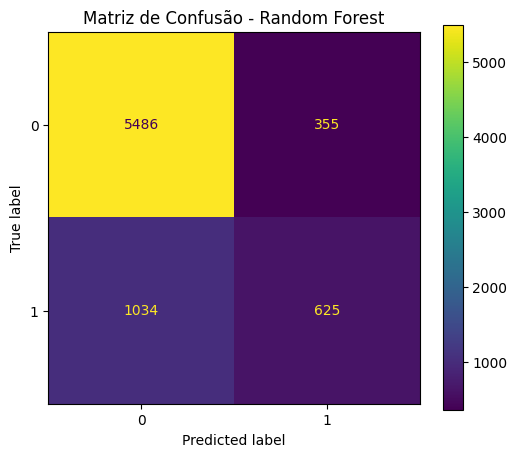

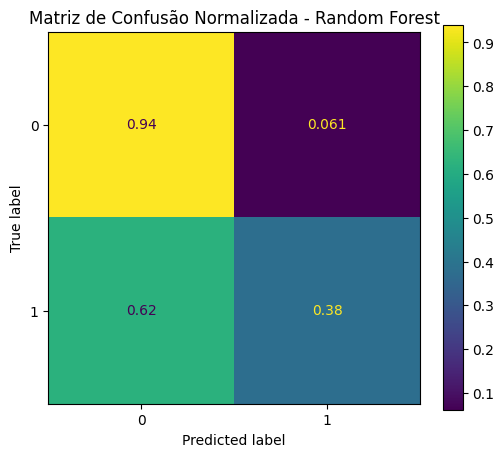

In [188]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    confusion_matrix
)

# 1. Modelo escolhido
chosen_model = forest
chosen_pred = y_pred_forest
chosen_prob = y_prob_forest

# 2. Matrizes de confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    chosen_pred,
    ax=ax
)
ax.set_title("Matriz de Confusão - Random Forest")
plt.show()


# Matriz normalizada pela classe real
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    chosen_pred,
    normalize="true",
    ax=ax
)
ax.set_title("Matriz de Confusão Normalizada - Random Forest")
plt.show()

In [189]:
# Obter TN, FP, FN e TP
tn, fp, fn, tp = confusion_matrix(
    y_test,
    chosen_pred
).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 5486
FP: 355
FN: 1034
TP: 625


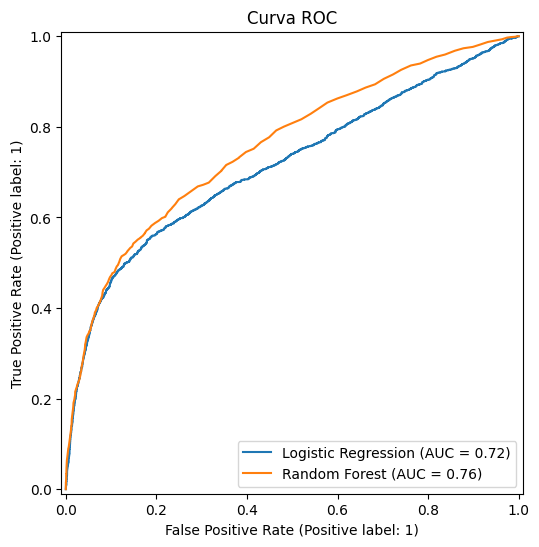

In [190]:
# 3. Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_forest,
    name="Random Forest",
    ax=ax
)

ax.set_title("Curva ROC")
plt.show()

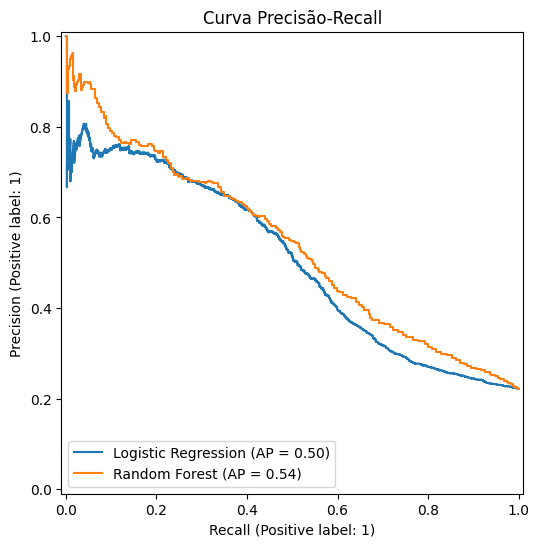

In [191]:
# 4. Curvas Precision-Recall
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_logistic,
    name="Logistic Regression",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_forest,
    name="Random Forest",
    ax=ax
)
ax.set_title("Curva Precisão-Recall")
plt.show()

In [192]:
# Threshold analysis
COST_FN = 10
COST_FP = 1
resultados = []

for t in np.arange(0.05, 1, 0.05):
    # Probabilidade -> classe
    y_pred = (chosen_prob >= t).astype(int)

    # TN, FP, FN, TP
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    resultados.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "FP": fp,
        "FN": fn,
        "custo": COST_FN * fn + COST_FP * fp
    })

threshold_df = pd.DataFrame(resultados)
display(threshold_df)

,threshold,precision,recall,f1,FP,FN,custo
0,0.05,0.239508,0.973478,0.384432,5128,44,5568
1,0.10,0.271066,0.893912,0.415989,3988,176,5748
2,0.15,0.326297,0.792043,0.462188,2713,345,6163
3,0.20,0.373129,0.691380,0.484682,1927,512,7047
4,0.25,0.435380,0.611212,0.508526,1315,645,7765
5,0.30,0.488594,0.555154,0.519752,964,738,8344
6,0.35,0.545984,0.508137,0.526382,701,816,8861
7,0.40,0.580377,0.463532,0.515416,556,890,9456
8,0.45,0.609778,0.413502,0.492816,439,973,10169
9,0.50,0.635176,0.380952,0.476262,363,1027,10633


In [193]:
melhor = threshold_df.loc[threshold_df["custo"].idxmin()]
print("Melhor threshold:", melhor["threshold"])
print("Menor custo:", melhor["custo"])

Melhor threshold: 0.05
Menor custo: 5568.0


## 4. Validação cruzada e extensão de regressão

### Classificação
Aplique `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` ao pipeline escolhido. Use `cross_validate` com `accuracy`, `precision`, `recall`, `f1`, `roc_auc` e `average_precision`. Produza uma tabela de média e desvio padrão.

### Regressão
Carregue `financial.csv`, normalize os nomes das colunas e converta campos monetários para numéricos. Preveja `profit`, mas remova de `X` as colunas `sales`, `cogs`, `gross_sales`, `discounts` e `date` quando existirem: elas revelam diretamente o lucro. Compare Ridge e Random Forest por MAE, RMSE e R², depois aplique K-Fold.

**Entrega:** em até cinco linhas, indique modelo, limiar e métrica principal para crédito, explicando o custo considerado; e interprete a métrica de regressão escolhida.

**Resposta:** Para **crédito, escolho o Random Forest**, usando o **limiar de menor custo encontrado na análise de threshold**.
A **métrica principal é o Recall**, pois queremos identificar o **maior número possível de inadimplentes**.
O **custo considerado foi 10 para FN e 1 para FP, tornando mais grave deixar um inadimplente passar**.
Para **regressão, escolho o modelo com menor MAE, pois essa métrica mostra o erro médio absoluto das previsões de lucro**.
Assim, um **MAE menor significa que, em média, as previsões ficam mais próximas do lucro real**.

In [194]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Validação estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Métricas
scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]

# Cross-validation no modelo escolhido
cv_result = cross_validate(
    forest,
    X,
    y,
    cv=cv,
    scoring=scoring
)

# Média e desvio padrão
cv_table = pd.DataFrame({
    "Média": [cv_result[f"test_{m}"].mean() for m in scoring],
    "Desvio padrão": [cv_result[f"test_{m}"].std() for m in scoring]
}, index=scoring)

display(cv_table)

,Média,Desvio padrão
accuracy,0.816600,0.002455
precision,0.648656,0.011268
recall,0.373116,0.006083
f1,0.473687,0.006416
roc_auc,0.765378,0.003868
average_precision,0.539110,0.006916


In [195]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carregar dados
financial = pd.read_csv("financial.csv", sep=",")

# Normalizar nomes das colunas
financial.columns = (
    financial.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(financial.columns.tolist())

['segment', 'country', 'product', 'discount_band', 'units_sold', 'manufacturing_price', 'sale_price', 'gross_sales', 'discounts', 'sales', 'cogs', 'profit', 'date', 'month_number', 'month_name', 'year']


In [196]:
financial.head()

,segment,country,product,discount_band,units_sold,manufacturing_price,sale_price,gross_sales,discounts,sales,cogs,profit,date,month_number,month_name,year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [203]:
# Converter colunas object para numérico quando possível
for col in financial.select_dtypes(include="object").columns:
    financial[col] = (
        financial[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("(", "-", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace("-", "0", regex=False)
        .str.strip()
    )

    financial[col] = pd.to_numeric(
        financial[col],
        errors="ignore"
    )

/tmp/ipykernel_7711/839736407.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  financial[col] = pd.to_numeric(
/tmp/ipykernel_7711/839736407.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  financial[col] = pd.to_numeric(
/tmp/ipykernel_7711/839736407.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  financial[col] = pd.to_numeric(
/tmp/ipykernel_7711/839736407.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  financial[col] = pd.to_numeric(
/tmp/ipykernel_7711/839736407.py:14: FutureWarning: errors='ignore' is d

In [204]:
financial.head()

,segment,country,product,discount_band,units_sold,manufacturing_price,sale_price,gross_sales,discounts,sales,cogs,profit,date,month_number,month_name,year
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,0.0,32370.0,16185.0,16185.0,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,0.0,26420.0,13210.0,13210.0,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,0.0,32670.0,21780.0,10890.0,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,0.0,13320.0,8880.0,4440.0,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,0.0,37050.0,24700.0,12350.0,01/06/2014,6,June,2014


In [205]:
# Remover linhas sem profit
financial = financial.dropna(subset=["profit"])

# Separar X e y
y_reg = financial["profit"]

# Colunas que não devem entrar no modelo
remover = ["profit", "sales", "cogs", "gross_sales", "discounts", "date"]

# Remover apenas as que existem
X_reg = financial.drop(
    columns=[c for c in remover if c in financial.columns]
)

# Usar apenas colunas numéricas
X_reg = X_reg.select_dtypes(include=np.number)

print(X_reg.shape)
print(y_reg.shape)

(700, 5)
(700,)


In [206]:
financial.head()

,segment,country,product,discount_band,units_sold,manufacturing_price,sale_price,gross_sales,discounts,sales,cogs,profit,date,month_number,month_name,year
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,0.0,32370.0,16185.0,16185.0,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,0.0,26420.0,13210.0,13210.0,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,0.0,32670.0,21780.0,10890.0,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,0.0,13320.0,8880.0,4440.0,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,0.0,37050.0,24700.0,12350.0,01/06/2014,6,June,2014


In [207]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

In [208]:
ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

forest_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Treinar
ridge.fit(X_train_r, y_train_r)
forest_reg.fit(X_train_r, y_train_r)

# Prever
pred_ridge = ridge.predict(X_test_r)
pred_forest = forest_reg.predict(X_test_r)

In [209]:
resultados_reg = pd.DataFrame({
    "Ridge": [
        mean_absolute_error(y_test_r, pred_ridge),
        np.sqrt(mean_squared_error(y_test_r, pred_ridge)),
        r2_score(y_test_r, pred_ridge)
    ],
    "Random Forest": [
        mean_absolute_error(y_test_r, pred_forest),
        np.sqrt(mean_squared_error(y_test_r, pred_forest)),
        r2_score(y_test_r, pred_forest)
    ]
}, index=["MAE", "RMSE", "R²"])

display(resultados_reg)

,Ridge,Random Forest
MAE,19466.067655,8541.543497
RMSE,30352.032440,18150.675704
R²,0.564193,0.844151


In [210]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring_reg = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_ridge = cross_validate(
    ridge,
    X_reg,
    y_reg,
    cv=kf,
    scoring=scoring_reg
)

cv_forest = cross_validate(
    forest_reg,
    X_reg,
    y_reg,
    cv=kf,
    scoring=scoring_reg
)

cv_reg = pd.DataFrame({
    "Ridge": [
        -cv_ridge["test_MAE"].mean(),
        -cv_ridge["test_RMSE"].mean(),
        cv_ridge["test_R2"].mean()
    ],
    "Random Forest": [
        -cv_forest["test_MAE"].mean(),
        -cv_forest["test_RMSE"].mean(),
        cv_forest["test_R2"].mean()
    ]
}, index=["MAE", "RMSE", "R²"])

display(cv_reg)

,Ridge,Random Forest
MAE,18585.161004,6562.106091
RMSE,27715.712601,13603.337682
R²,0.535936,0.886418
